In [1]:
 # Sample random rotation matrices
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats.sampling import NumericalInversePolynomial

class UniformAngle:
    """This distribution of angles corresponds to the Haar distribution on SO(3)."""
    def __init__(self):
        self.domain = (0, np.pi)
    def pdf(self, x):
        return (1 - np.cos(x)) / np.pi

angle_distribution = UniformAngle()

angle_sampler = NumericalInversePolynomial(
    dist = angle_distribution,
    domain = angle_distribution.domain,
)

def sample_angles(n_samples, random=False):
    if random:
        return angle_sampler.rvs(n_samples)
    else:
        t = np.linspace(0, 1, n_samples)
        return angle_sampler.ppf(t)


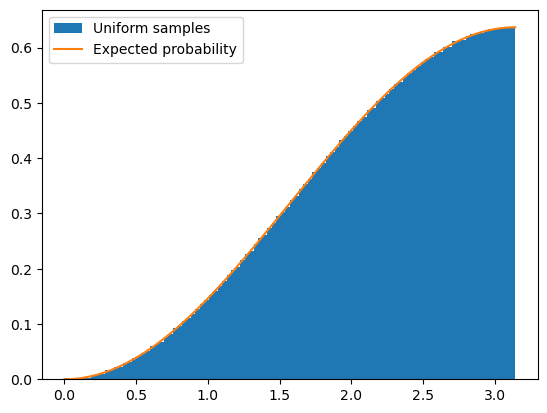

In [2]:
plt.hist(sample_angles(n_samples=10000), bins=100, density=True, label="Uniform samples")

x = np.linspace(0, np.pi, 1000)
plt.plot(x, angle_distribution.pdf(x), label="Expected probability")

plt.legend()

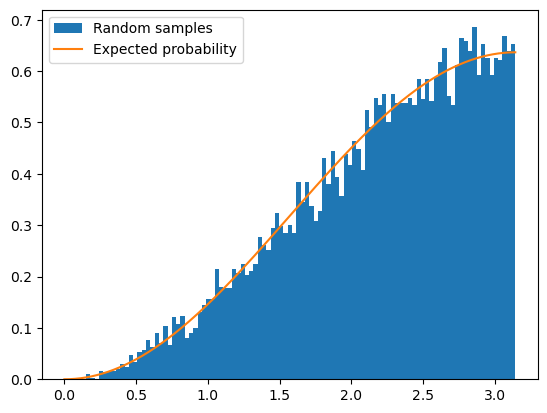

In [3]:
plt.hist(sample_angles(n_samples=10000, random=True), bins=100, density=True, label="Random samples")

x = np.linspace(0, np.pi, 1000)
plt.plot(x, angle_distribution.pdf(x), label="Expected probability")

plt.legend()

In [4]:
def sample_directions(n_samples, random=False):
    if random:
        points = np.random.randn(n_samples, 3)
        points /= np.linalg.norm(points, axis=1)[:, None]
        return points
    else:
        # Fibonacci sphere, 
        # https://stackoverflow.com/questions/9600801/evenly-distributing-n-points-on-a-sphere
        points = []
        phi = np.pi * (np.sqrt(5.) - 1.)  # golden angle in radians
        i = np.arange(n_samples)
        y = 1 - (i / float(n_samples - 1)) * 2  # y goes from 1 to -1
        radius = np.sqrt(1 - y * y)
        theta = phi * i
        x = np.cos(theta) * radius
        z = np.sin(theta) * radius
        points = np.stack((x, y, z), axis=1)

        return points

In [5]:
# Display the distribution of directions in 3D using PyVista
import pyvista as pv
pv.set_jupyter_backend("static")

def display_points(points):
    cloud = pv.PolyData(points)
    pl = pv.Plotter(window_size=[400, 400])
    point_size = 30 * 10 / np.sqrt(len(points))
    pl.add_mesh(cloud, scalars = points[:, 1], cmap="RdBu", point_size=point_size, render_points_as_spheres=True)
    pl.enable_anti_aliasing("ssaa")
    pl.camera_position = "xz"
    pl.enable_parallel_projection()
    pl.show()


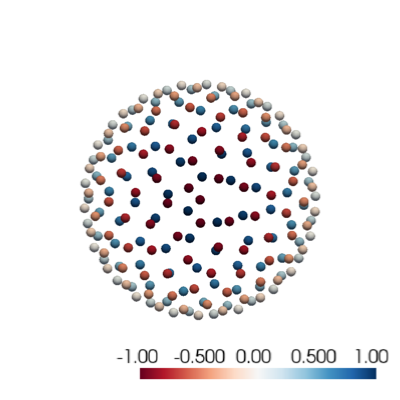

In [6]:
display_points(sample_directions(n_samples=200, random=False))


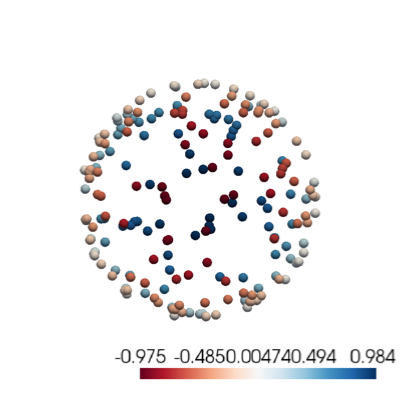

In [7]:
display_points(sample_directions(n_samples=200, random=True))

In [8]:
def sample_vectors(n_samples, random=False):
    if random:
        angles = sample_angles(n_samples, random=random)
        directions = sample_directions(n_samples, random=random)
        vectors = (angles[:, None] * directions).reshape(-1, 3)
    else:
        n_angles = int(.5 * (n_samples ** (1/3)))
        n_directions = n_samples // n_angles
        angles = sample_angles(n_angles, random=random)
        directions = sample_directions(n_directions, random=random)
        angles = angles[:, None, None]
        directions = directions[None, :, :]
        vectors = (angles * directions).reshape(-1, 3)

    # print(np.linalg.norm(vectors, axis=1).mean())
    print(vectors.shape)
    return vectors

(1000, 3)


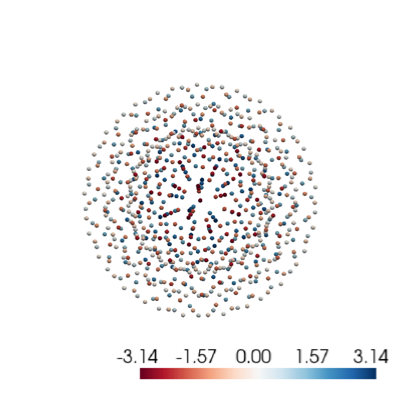

In [9]:
display_points(sample_vectors(n_samples=1000, random=False))

(1000, 3)


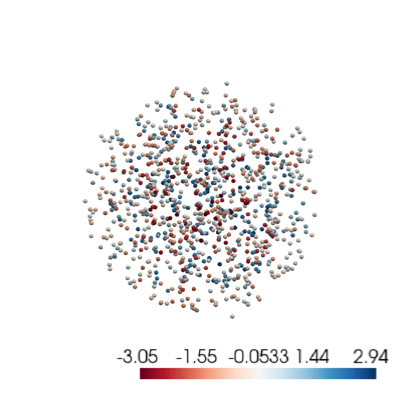

In [10]:
display_points(sample_vectors(n_samples=1000, random=True))